In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

print(Path.cwd())

d:\Anisha\Projects\EuroSAT\notebooks


In [31]:
from sklearn.model_selection import train_test_split
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from src.visualisation import *
from src.config import *
from src.utils import *
import numpy as np
import pandas as pd
import rasterio
import random
import os

# Dataset Classes 

In [3]:
CLASSES = [i.name for i in RGB_PATH.iterdir()]
NUM_CLASSES = len(CLASSES)

print('CLASSES : ', CLASSES)
print('Total Number of Classes : ', NUM_CLASSES)


CLASSES :  ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total Number of Classes :  10


# Dataset Class Items

RGB CLASSES COUNT :  [{'AnnualCrop': 3000}, {'Forest': 3000}, {'HerbaceousVegetation': 3000}, {'Highway': 2500}, {'Industrial': 2500}, {'Pasture': 2000}, {'PermanentCrop': 2500}, {'Residential': 3000}, {'River': 2500}, {'SeaLake': 3000}]
MS CLASSES COUNT :  [{'AnnualCrop': 3000}, {'Forest': 3000}, {'HerbaceousVegetation': 3000}, {'Highway': 2500}, {'Industrial': 2500}, {'Pasture': 2000}, {'PermanentCrop': 2500}, {'Residential': 3000}, {'River': 2500}, {'SeaLake': 3000}]
RGB TOTAL IMAGES :  27000
MS TOTAL IMAGES :  27000


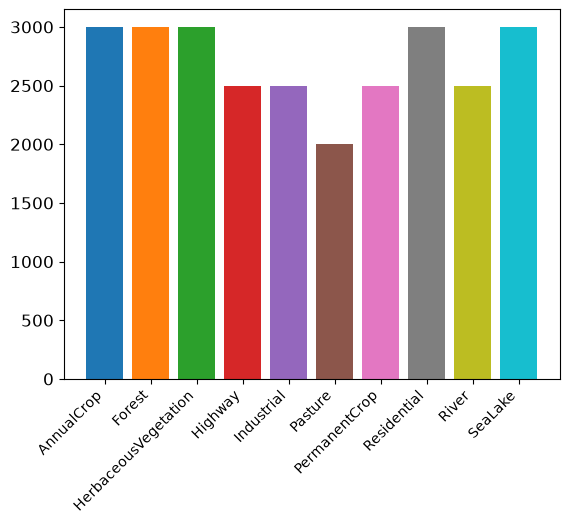

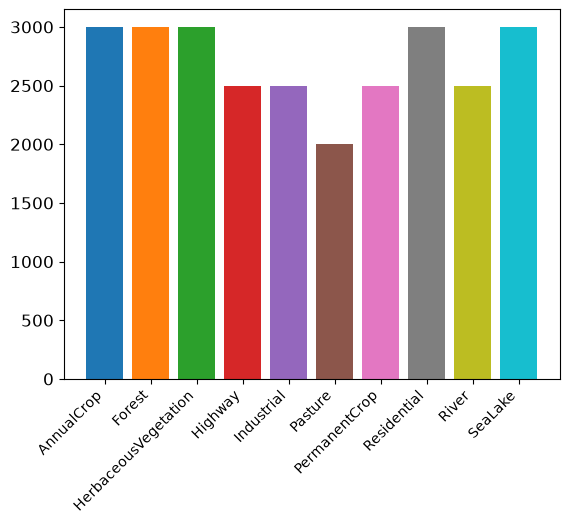

In [4]:

rgb_files = count_files(CLASSES, RGB_PATH, 'jpg')
ms_files = count_files(CLASSES, MS_PATH, 'tif')

print('RGB CLASSES COUNT : ', rgb_files)
print('MS CLASSES COUNT : ', ms_files)

print('RGB TOTAL IMAGES : ', sum(list(i.values())[0] for i in rgb_files))
print('MS TOTAL IMAGES : ', sum(list(i.values())[0] for i in ms_files))

for i in rgb_files:
    plt.bar(i.keys(), i.values())
    plt.xticks(rotation=45, ha='right')
    plt.yticks(fontsize=12)
    plt.savefig(
        RGB_CLASS_DISTRIBUTION, dpi=300
    )
plt.show()

for i in ms_files:
    plt.bar(i.keys(), i.values())
    plt.xticks(rotation=45, ha='right')
    plt.yticks(fontsize=12)
    plt.savefig(
        MS_CLASS_DISTRIBUTION, dpi=300
    )
plt.show()

# Image Validation

In [5]:
#RGB Image Validation

rgb_k = rgb_files[random.randrange(0, 10)]
rgb_img = random.randrange(0, 2000)
cl = list(rgb_k.keys())[0]

im_rgb = cl + '_' + str(rgb_img) + '.jpg'
im_ms = cl + '_' + str(rgb_img) + '.tif'

temp_rgb_path = RGB_PATH /  cl / im_rgb

image_rgb = Image.open(temp_rgb_path)
image_rgb = np.array(image_rgb)


In [6]:
# MS Image Validation

temp_ms_path = MS_PATH /  cl / im_ms

with rasterio.open(temp_ms_path) as src:
    image_ms = src.read()

    print(src.count)

# MS Bands

for i, band in enumerate(BAND_NAMES):
    im_band = image_ms[i]

    print(band)
    print('SHAPE : MS=', im_band.shape)
    print('MIN VALUE : MS=', im_band.min())
    print('MAX VALUE : MS=', im_band.max())
    print('DTYPE : MS=', im_band.dtype)
    print()


# Display RGB using MS Bands

r = image_ms[3]
g = image_ms[2]
b = image_ms[1]

rgb_ms = np.stack([r, g, b], axis=-1)
rgb_ms = rgb_ms.astype('float32')
rgb_ms8 = (rgb_ms - rgb_ms.min()) / (rgb_ms.max() - rgb_ms.min() + 1e-8)


13
B01
SHAPE : MS= (64, 64)
MIN VALUE : MS= 1138
MAX VALUE : MS= 1216
DTYPE : MS= uint16

B02
SHAPE : MS= (64, 64)
MIN VALUE : MS= 778
MAX VALUE : MS= 1363
DTYPE : MS= uint16

B03
SHAPE : MS= (64, 64)
MIN VALUE : MS= 578
MAX VALUE : MS= 1389
DTYPE : MS= uint16

B04
SHAPE : MS= (64, 64)
MIN VALUE : MS= 385
MAX VALUE : MS= 1648
DTYPE : MS= uint16

B05
SHAPE : MS= (64, 64)
MIN VALUE : MS= 738
MAX VALUE : MS= 1546
DTYPE : MS= uint16

B06
SHAPE : MS= (64, 64)
MIN VALUE : MS= 1491
MAX VALUE : MS= 3569
DTYPE : MS= uint16

B07
SHAPE : MS= (64, 64)
MIN VALUE : MS= 1789
MAX VALUE : MS= 4827
DTYPE : MS= uint16

B08
SHAPE : MS= (64, 64)
MIN VALUE : MS= 1609
MAX VALUE : MS= 5066
DTYPE : MS= uint16

B09
SHAPE : MS= (64, 64)
MIN VALUE : MS= 1138
MAX VALUE : MS= 1894
DTYPE : MS= uint16

B10
SHAPE : MS= (64, 64)
MIN VALUE : MS= 13
MAX VALUE : MS= 19
DTYPE : MS= uint16

B11
SHAPE : MS= (64, 64)
MIN VALUE : MS= 1078
MAX VALUE : MS= 2372
DTYPE : MS= uint16

B12
SHAPE : MS= (64, 64)
MIN VALUE : MS= 508
MAX

In [7]:
# RGB & MS IMAGE INFO

print('SHAPE : RGB=', image_rgb.shape, ', MS=', image_ms.shape)
print('MIN VALUE : RGB=', image_rgb.min(), ', MS=', image_ms.min())
print('MAX VALUE : RGB=', image_rgb.max(), ', MS=', image_ms.max())
print('DTYPE : RGB=', image_rgb.dtype, ', MS=', image_ms.dtype)


SHAPE : RGB= (64, 64, 3) , MS= (13, 64, 64)
MIN VALUE : RGB= 37 , MS= 13
MAX VALUE : RGB= 141 , MS= 5253
DTYPE : RGB= uint8 , MS= uint16


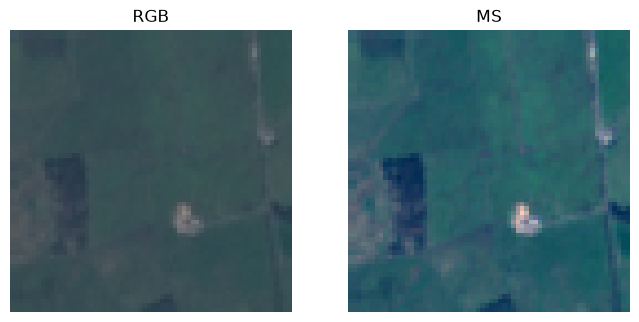

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(image_rgb)
axes[0].set_title('RGB')
axes[0].axis('off')

axes[1].imshow(rgb_ms8)
axes[1].set_title('MS')
axes[1].axis('off')


plt.savefig(
       RAW_RGB_MS , dpi=300
    )
plt.show()


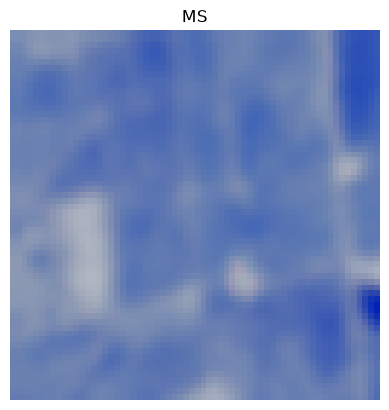

In [9]:
# Band visualisation Check - Random Bands
 
new_band = [image_ms[3], image_ms[4], image_ms[5], image_ms[6]]
ms_im8 = ms_visualisation_uint8(new_band)

plt.savefig(
       RAW_MS_CHECK , dpi=300
    )

plt.imshow(ms_im8)
plt.title('MS')
plt.axis('off')
plt.show()


# Creating the DataFrame

In [10]:
rgb_df = build_df(CLASSES, RGB_PATH, 'jpg')
ms_df = build_df(CLASSES, MS_PATH, 'tif')

display(rgb_df.head())
display(ms_df.head())

print('Total RGB Samples : ', len(rgb_df))
print('Total MS Samples : ', len(ms_df))

,path,label,image_id
0,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop,AnnualCrop_1
1,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop,AnnualCrop_10
2,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop,AnnualCrop_100
3,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop,AnnualCrop_1000
4,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop,AnnualCrop_1001


,path,label,image_id
0,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop,AnnualCrop_1
1,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop,AnnualCrop_10
2,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop,AnnualCrop_100
3,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop,AnnualCrop_1000
4,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop,AnnualCrop_1001


Total RGB Samples :  27000
Total MS Samples :  27000


In [11]:
ms_df.head()

,path,label,image_id
0,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop,AnnualCrop_1
1,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop,AnnualCrop_10
2,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop,AnnualCrop_100
3,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop,AnnualCrop_1000
4,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop,AnnualCrop_1001


In [12]:
# Creating a combined dataframe - for fair comparison

df = pd.merge(rgb_df, ms_df, on=['image_id', 'label'], suffixes=('_rgb', '_ms'))

df.head()

,path_rgb,label,image_id,path_ms
0,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop,AnnualCrop_1,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...
1,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop,AnnualCrop_10,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...
2,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop,AnnualCrop_100,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...
3,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop,AnnualCrop_1000,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...
4,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop,AnnualCrop_1001,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...


In [13]:
# Checking for Dupplicates

rgb_duplicates = rgb_df.duplicated(subset=['image_id', 'label'], keep=False)
ms_duplicates = ms_df.duplicated(subset=['image_id', 'label'], keep=False)

print('RGB Duplicates : ', rgb_duplicates.sum())
print('MS Duplicates : ', ms_duplicates.sum())

if rgb_duplicates.sum() > 0:
    display(rgb_df[rgb_duplicates])

if ms_duplicates.sum() > 0:
    display(ms_df[ms_duplicates])

RGB Duplicates :  0
MS Duplicates :  0


In [14]:
# Train, Validation and Test Split

train_data, val_test = train_test_split(
    df, test_size = TRAIN_SPLIT, stratify=df['label'], random_state=42
)

val_data, test_data = train_test_split(
    val_test, test_size=TEST_SPLIT, stratify=val_test['label'], random_state=42
)

print('Dataset Split : Train = ', len(train_data), 
      ', Val = ', len(val_data), 
      ', Test = ', len(test_data))


# Save the Train Test Val Split datasets

train_data.to_csv(SPLITS_DIR / 'train.csv', index=False)
test_data.to_csv(SPLITS_DIR / 'val.csv', index=False)
val_data.to_csv(SPLITS_DIR / 'test.csv', index=False)


Dataset Split : Train =  18360 , Val =  3240 , Test =  5400


In [32]:
import importlib
import src.visualisation

importlib.reload(src.visualisation)

<module 'src.visualisation' from 'd:\\Anisha\\Job\\Aston_University\\EuroSAT\\src\\visualisation.py'>

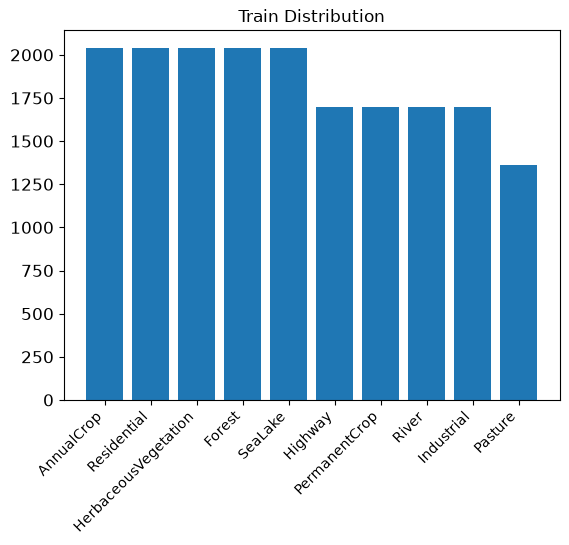

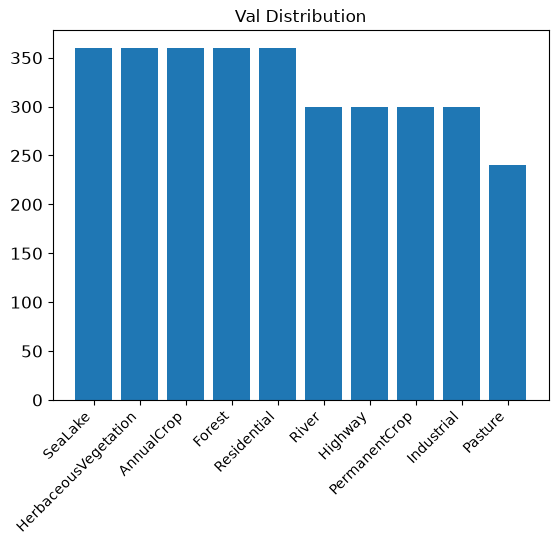

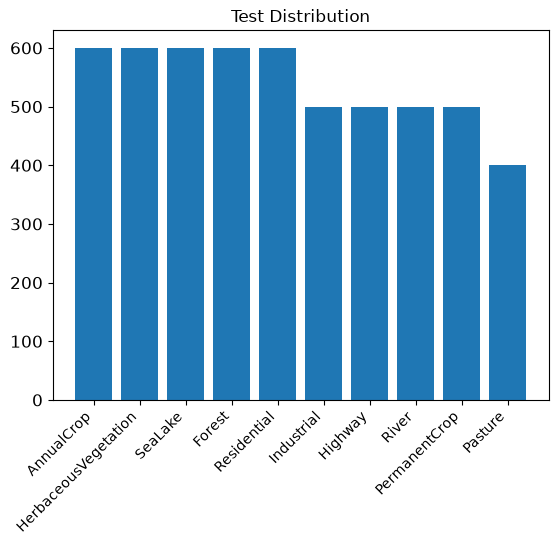

In [33]:
# Dataset Distribution Validation

tr = train_data['label'].value_counts()
plt1 = plot_bar_graph(tr.index, tr.values, 'Train Distribution', DATASET_TRAIN_SPLIT_FIG)

vl = val_data['label'].value_counts()
plt2 = plot_bar_graph(vl.index, vl.values, 'Val Distribution', DATASET_VAL_SPLIT_FIG)

ts = test_data['label'].value_counts()
plt3 = plot_bar_graph(ts.index, ts.values, 'Test Distribution', DATASET_TEST_SPLIT_FIG)

